# OmniParser Smoke Test

In [1]:
# 1. create symlink between models/omniparser to weights
# ln  -s  ./models/omniparser/ ./external/OmniParser/weights

import sys
import os
sys.path.insert(0, '../external/OmniParser/')
sys.path.insert(0, '..')

%load_ext autoreload
%autoreload 2

In [2]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from ultralytics import YOLO
from torchvision.transforms import ToPILImage

from src.utils import get_xywh, get_xyxy, to_numpy, visualize_boxes, int_box_area, C2A_PALETTE
model_path='../models/omniparser/icon_detect_v1_5/model_v1_5.pt'
device = 'cuda'

In [3]:
image_path = '../imgs/onenote.png'
image = Image.open(image_path)
image_rgb = image.convert('RGB')
image_np = np.array(image_rgb)
w, h = image_rgb.size
print('image size:', w, h)

box_overlay_ratio = max(image.size) / 3200
draw_bbox_config = {
    'text_scale': 0.8 * box_overlay_ratio,
    'text_thickness': max(int(2 * box_overlay_ratio), 1),
    'text_padding': max(int(3 * box_overlay_ratio), 1),
    'thickness': max(int(3 * box_overlay_ratio), 1),
}

# confidence threshold to filter ocr results
text_threshold = 0.9
# confidence threshold to filter icond dectection results
box_threshold = 0.05
# when icon detection model output two icons with IoU > iou_threshold -> we keep smaller ones
iou_threshold = 0.7

image size: 1919 1079


## 1. Get OCR Boxes

In [4]:
from paddleocr import PaddleOCR

paddle_ocr = PaddleOCR(
        lang='en',
        use_angle_cls=False,
        use_gpu=False,
        show_log=False,
        max_batch_size=1024,
        use_dilation=True,
        det_db_score_mode='slow',
        rec_batch_num=1024)

In [5]:
ocr_result = paddle_ocr.ocr(image_np, cls=False)[0] # [[p1, p2, p3, p4], (text, confidence)]
# [[[[888.0, 6.0], [1037.0, 6.0], [1037.0, 28.0], [888.0, 28.0]],
#   ('OneNote for Windows 10.', 0.9537414312362671)],
#  [[[1657.0, 8.0], [1717.0, 8.0], [1717.0, 28.0], [1657.0, 28.0]],
#   ('Yadong Lu', 0.9674320220947266)],

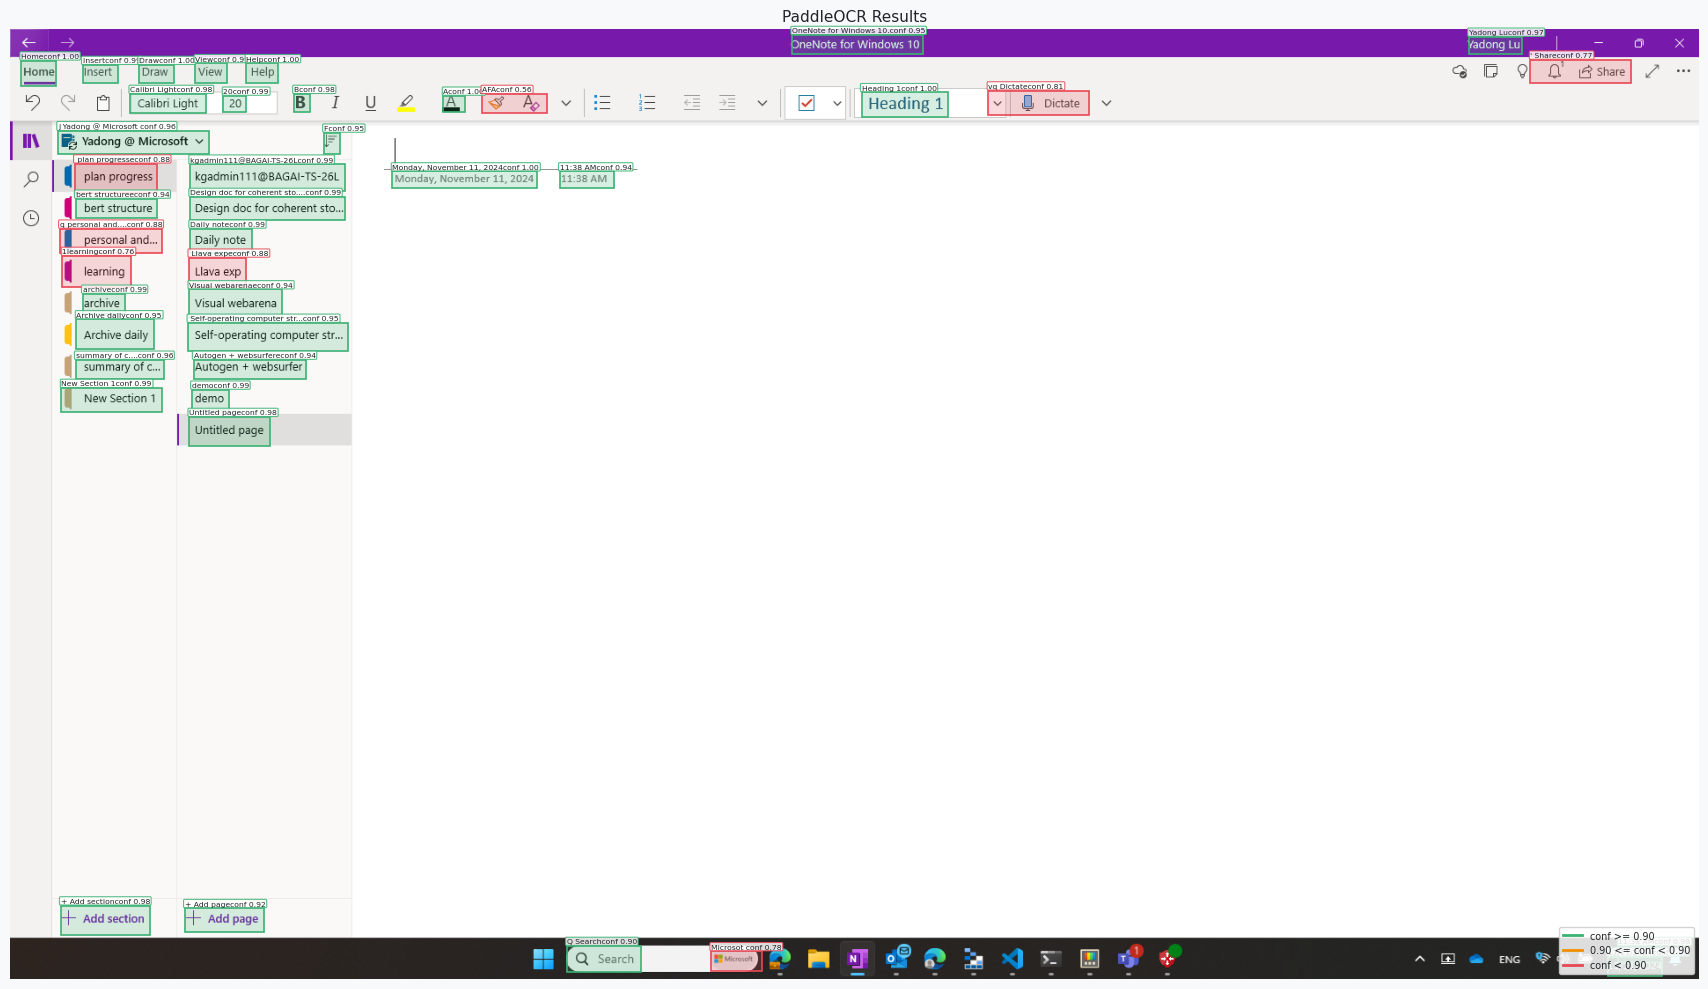

In [6]:
# from PaddleOCR (pixel coords)
ocr_boxes = np.array([get_xyxy(item[0]) for item in ocr_result], dtype=np.float32)
ocr_confs  = np.array([item[1][1] for item in ocr_result])
ocr_labels = [item[1][0] + f'conf {item[1][1]:.2f}' for item in ocr_result]

visualize_boxes(image_np, ocr_boxes, confidences=ocr_confs, mid_conf=text_threshold, labels=ocr_labels,
                title="PaddleOCR Results")

In [7]:
ocr_result

[[[[888.0, 6.0], [1037.0, 6.0], [1037.0, 28.0], [888.0, 28.0]],
  ('OneNote for Windows 10.', 0.9537414312362671)],
 [[[1657.0, 8.0], [1717.0, 8.0], [1717.0, 28.0], [1657.0, 28.0]],
  ('Yadong Lu', 0.9674320220947266)],
 [[[12.0, 35.0], [55.0, 41.0], [52.0, 64.0], [9.0, 59.0]],
  ('Home', 0.9965360164642334)],
 [[[82.0, 40.0], [122.0, 40.0], [122.0, 61.0], [82.0, 61.0]],
  ('Insert', 0.990497350692749)],
 [[[146.0, 40.0], [186.0, 40.0], [186.0, 61.0], [146.0, 61.0]],
  ('Draw', 0.997331976890564)],
 [[[210.0, 38.0], [246.0, 38.0], [246.0, 61.0], [210.0, 61.0]],
  ('View', 0.9937258362770081)],
 [[[268.0, 38.0], [304.0, 38.0], [304.0, 61.0], [268.0, 61.0]],
  ('Help', 0.9978308081626892)],
 [[[1727.0, 34.0], [1841.0, 34.0], [1841.0, 61.0], [1727.0, 61.0]],
  ("' Share", 0.7696714997291565)],
 [[[136.0, 73.0], [222.0, 73.0], [222.0, 95.0], [136.0, 95.0]],
  ('Calibri Light', 0.9819532036781311)],
 [[[242.0, 75.0], [268.0, 75.0], [268.0, 93.0], [242.0, 93.0]],
  ('20', 0.9879754781723022)

In [8]:
ocr_coord = [item[0] for item in ocr_result if item[1][1] > text_threshold]
ocr_text = [item[1][0] for item in ocr_result if item[1][1] > text_threshold]

ocr_bbox = torch.tensor([get_xyxy(item) for item in ocr_coord]) / torch.Tensor([w, h, w, h])

## 2. Icon Detection

In [9]:
# Load the model.
som_model = YOLO(model_path)
som_model.to(device)

icon_det_result = som_model.predict(
    source=image_rgb,
    conf=0.05,
    iou=0.1,
)


0: 736x1280 83 icons, 185.8ms
Speed: 22.7ms preprocess, 185.8ms inference, 486.5ms postprocess per image at shape (1, 3, 736, 1280)


In [10]:
icon_det_boxes = icon_det_result[0].boxes.xyxy / torch.Tensor([w, h, w, h]).to(som_model.device) # normalize bboxs to [0,1] by dividing with w,h
icon_det_conf = icon_det_result[0].boxes.conf
icon_det_phrases = [str(i) for i in range(len(icon_det_boxes))]
# normalize

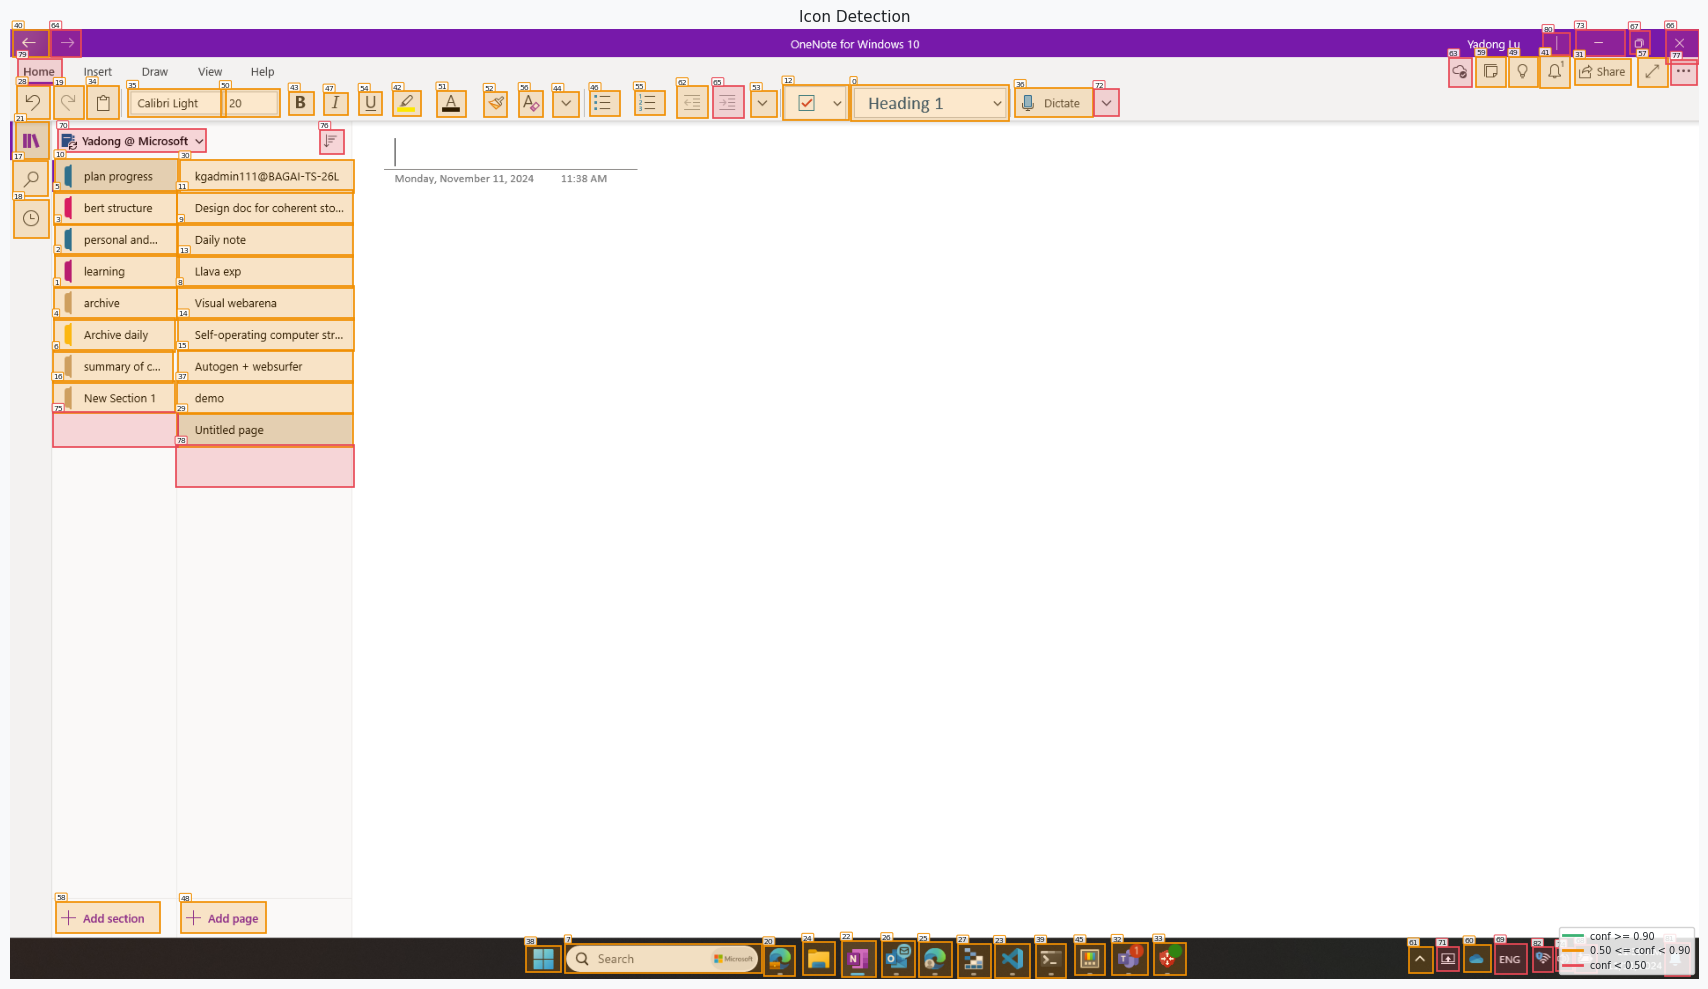

In [11]:
# from YOLO (Tensor, normalised)
visualize_boxes(image_np, icon_det_boxes, confidences=icon_det_conf,
                labels=icon_det_phrases, title="Icon Detection")

## 3. Merge Icons

* Step 1 — IoU helper (custom)
The IoU function is not standard IoU. It returns max(standard_IoU, ratio1, ratio2) where ratio1/2 = intersection /
area of each box individually. This means even if one box is fully inside the other, the overlap is caught
(containment → ratio = 1.0).

* Step 2 — Icon-vs-icon NMS
For each icon box box1, check all other icon boxes box2:
- If IoU > iou_threshold AND box1 is larger than box2 → discard box1 (keep the smaller box).

This is inverse of standard NMS (keeps small boxes, not high-confidence ones).

* Step 3 — Icon vs OCR merging (only if ocr_bbox provided)
For each surviving icon box, scan all OCR boxes:
```
┌───────────────────────────────────────┬──────────────────────────────────────────────────────────────┐
│           Spatial relation            │                            Action                            │
├───────────────────────────────────────┼──────────────────────────────────────────────────────────────┤
│ OCR box is inside icon (>80% overlap) │ Remove OCR box from output; collect its text into ocr_labels │
├───────────────────────────────────────┼──────────────────────────────────────────────────────────────┤
│ Icon is inside OCR box                │ Discard the icon entirely (box_added = True)                 │
├───────────────────────────────────────┼──────────────────────────────────────────────────────────────┤
│ No overlap                            │ Skip                                                         │
└───────────────────────────────────────┴──────────────────────────────────────────────────────────────┘
```

After scanning, append the icon with:
- source: box_yolo_content_ocr + merged OCR text if any text was absorbed
- source: box_yolo_content_yolo + content: None if no OCR overlap

* Step 4 — Output
Returns a flat list starting with all OCR boxes (unmodified ones remain), followed by surviving icon boxes
(potentially enriched with absorbed OCR text).


In [12]:
def box_area(box):
    return (box[2] - box[0]) * (box[3] - box[1])

def intersection_area(box1, box2):
    x1, y1 = max(box1[0], box2[0]), max(box1[1], box2[1])
    x2, y2 = min(box1[2], box2[2]), min(box1[3], box2[3])
    return max(0, x2 - x1) * max(0, y2 - y1)

def overlap_score(box1, box2):
    """max(IoU, containment ratio of box1, containment ratio of box2)."""
    inter = intersection_area(box1, box2)
    union = box_area(box1) + box_area(box2) - inter + 1e-6
    ratio1 = inter / box_area(box1) if box_area(box1) > 0 else 0
    ratio2 = inter / box_area(box2) if box_area(box2) > 0 else 0
    return max(inter / union, ratio1, ratio2)

def is_inside(box1, box2, threshold=0.80):
    """True if box1 is at least `threshold` contained within box2."""
    inter = intersection_area(box1, box2)
    return (inter / box_area(box1)) > threshold if box_area(box1) > 0 else False

def merge_icons_ocr_boxes(boxes, iou_threshold, ocr_bbox=None):
    """
    Merge YOLO icon boxes with OCR text boxes, resolving spatial overlaps.

    Args:
        boxes      : list of icon dicts  {'type', 'bbox': [x1,y1,x2,y2], 'interactivity', 'content'}
        iou_threshold: overlap threshold for icon-vs-icon NMS (keeps smaller box)
        ocr_bbox   : list of OCR dicts   {'type', 'bbox': [x1,y1,x2,y2], 'interactivity', 'content'}
                    or None to skip OCR merging

    Returns:
        filtered_boxes: merged list of surviving OCR + icon dicts
    """
    removed_ocr_indices = set()

    surviving_icons = []

    for i, box1_elem in enumerate(boxes):
        box1 = box1_elem['bbox']

        # Icon-vs-icon NMS: discard box1 if a smaller box overlaps it above threshold
        dominated = any(
            i != j
            and overlap_score(box1, box2_elem['bbox']) > iou_threshold
            and box_area(box1) > box_area(box2_elem['bbox'])
            for j, box2_elem in enumerate(boxes)
        )
        if dominated:
            continue

        if not ocr_bbox:
            surviving_icons.append(box1)
            continue

        # Icon-vs-OCR merging
        absorbed_labels = []
        icon_absorbed_by_ocr = False

        for k, ocr_elem in enumerate(ocr_bbox):
            ocr_box = ocr_elem['bbox']
            if is_inside(ocr_box, box1):            # OCR box inside icon → absorb
                print(f"ocr-box is inside ", ocr_elem['content'])
                absorbed_labels.append(ocr_elem['content'])
                removed_ocr_indices.add(k)
            elif is_inside(box1, ocr_box):          # icon inside OCR box → drop icon
                print(f"ocr-box is inside ", ocr_elem['content'])
                icon_absorbed_by_ocr = True
                break

        if icon_absorbed_by_ocr:
            continue

        merged_content = ' '.join(absorbed_labels) if absorbed_labels else None
        source = 'box_yolo_content_ocr' if absorbed_labels else 'box_yolo_content_yolo'
        surviving_icons.append({
            'type': 'icon',
            'bbox': box1_elem['bbox'],
            'interactivity': True,
            'content': merged_content,
            'source': source,
        })

    surviving_ocr = [elem for k, elem in enumerate(ocr_bbox or []) if k not in removed_ocr_indices]
    return surviving_ocr + surviving_icons

In [13]:
ocr_bbox_elem = [{'type': 'text', 'bbox':box.cpu().numpy(), 'interactivity':False, 'content':txt, 'source': 'box_ocr_content_ocr'} 
                 for box, txt in zip(ocr_bbox, ocr_text) 
                 if int_box_area(box, w, h) > 0] 

icon_bbox_elem = [{'type': 'icon', 'bbox':box, 'interactivity':True, 'content':None} 
             for box in icon_det_boxes.tolist() 
             if int_box_area(box, w, h) > 0]

filtered_boxes = merge_icons_ocr_boxes(boxes=icon_bbox_elem, iou_threshold=iou_threshold, ocr_bbox=ocr_bbox_elem)


ocr-box is inside  Heading 1
ocr-box is inside  archive
ocr-box is inside  Archive daily
ocr-box is inside  bert structuree
ocr-box is inside  summary of c....
ocr-box is inside  Q Search
ocr-box is inside  Visual webarenae
ocr-box is inside  Daily note
ocr-box is inside  Design doc for coherent sto....
ocr-box is inside   Self-operating computer str...
ocr-box is inside  Autogen + websurfere
ocr-box is inside  New Section 1
ocr-box is inside  Untitled page
ocr-box is inside  kgadmin111@BAGAI-TS-26L
ocr-box is inside  Calibri Light
ocr-box is inside  demo
ocr-box is inside  B
ocr-box is inside  + Add page
ocr-box is inside  20
ocr-box is inside  A
ocr-box is inside  + Add section
ocr-box is inside  j Yadong @ Microsoft 
ocr-box is inside  F
ocr-box is inside  Home


In [14]:
filtered_boxes[0]

{'type': 'text',
 'bbox': array([    0.46274,   0.0055607,     0.54039,     0.02595], dtype=float32),
 'interactivity': False,
 'content': 'OneNote for Windows 10.',
 'source': 'box_ocr_content_ocr'}

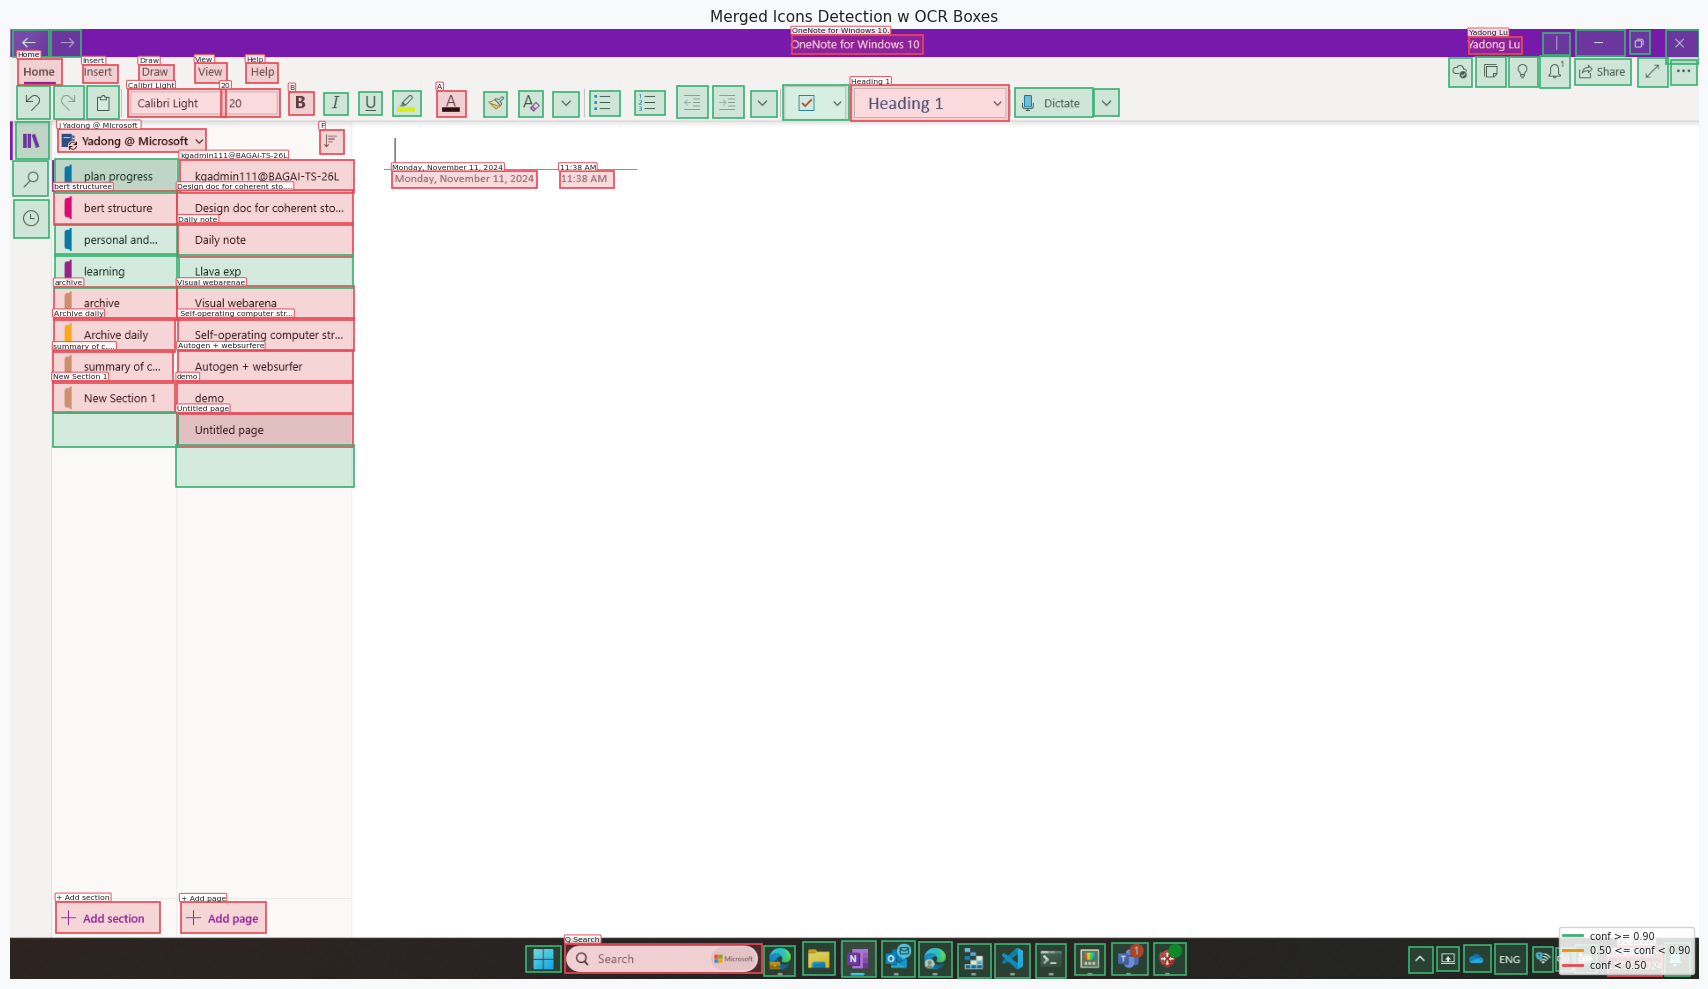

In [15]:
visualize_boxes(image_np, [elem['bbox'] for elem in filtered_boxes], 
                labels=[elem['content'] for elem in filtered_boxes], 
                confidences=[0.2 if 'ocr' in elem['source'] else 1 for elem in filtered_boxes], 
                title="Merged Icons Detection w OCR Boxes")

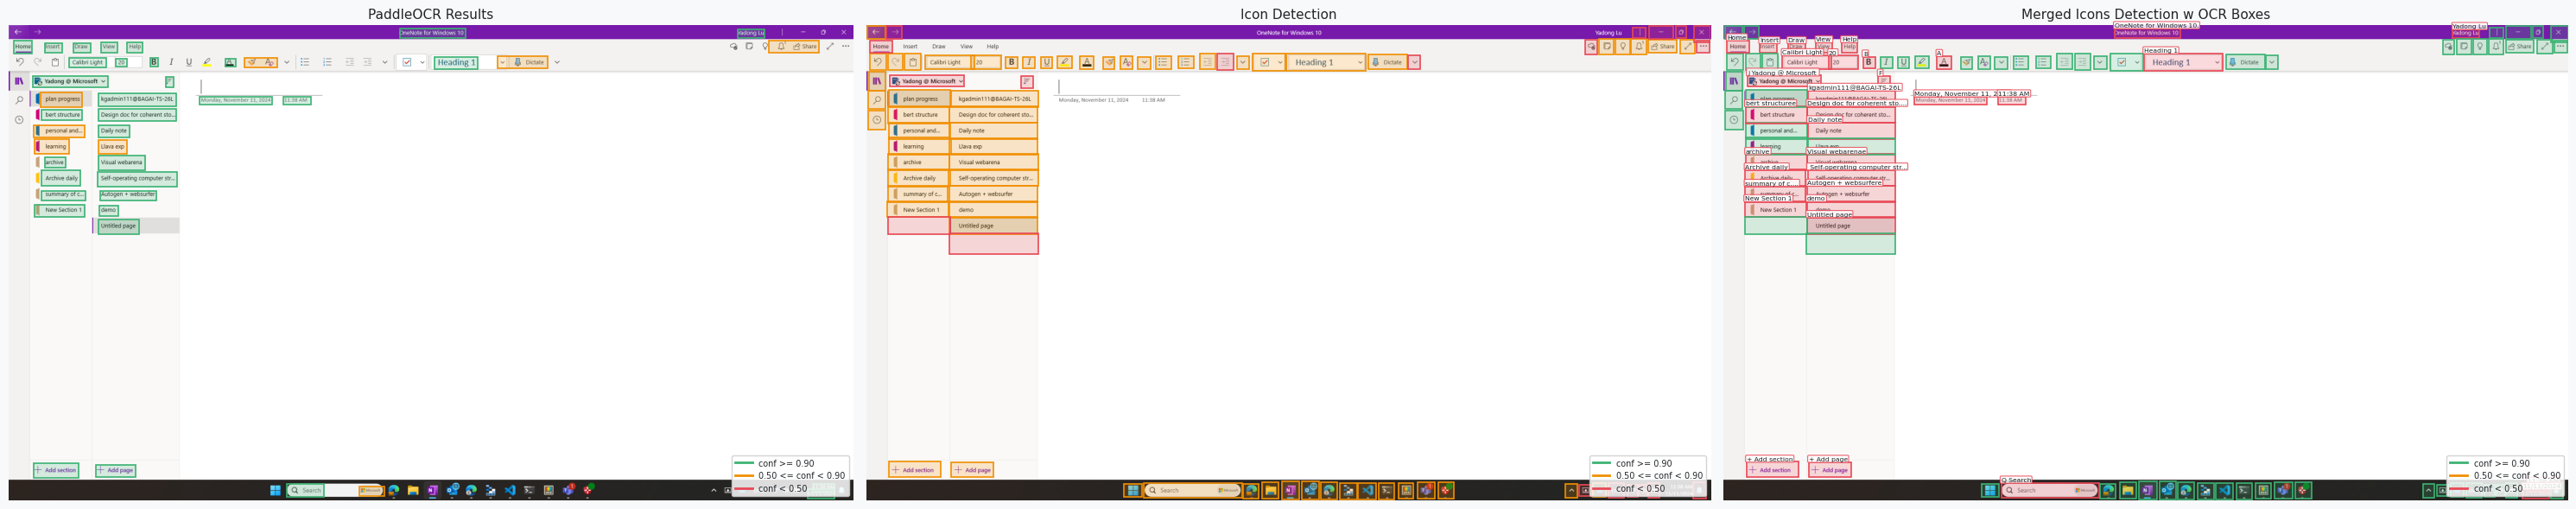

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(10 * 3, 8))
fig.patch.set_facecolor(C2A_PALETTE["bg"])

visualize_boxes(image_np, ocr_boxes, confidences=ocr_confs,
                title="PaddleOCR Results", ax=axes[0])

visualize_boxes(image_np, icon_det_boxes, confidences=icon_det_conf, title="Icon Detection", ax=axes[1])
  
visualize_boxes(image_np, [elem['bbox'] for elem in filtered_boxes], 
                labels=[elem['content'] for elem in filtered_boxes], 
                confidences=[0.2 if 'ocr' in elem['source'] else 1 for elem in filtered_boxes], 
                title="Merged Icons Detection w OCR Boxes", ax=axes[2])

plt.tight_layout()
plt.show()


the red boxs are the ocr boxs which will be flagged to be text boxs that shouldn't be interactive??

***Note***: the only thing detected by OCR was the username on the top bar

# 4 Caption Icons

* there were two problem in old code
    * it resizes cropped icon into 64 without taking into account aspect-ration
    * it resized into 64 -> even so 128 is better

In [17]:
from transformers import AutoProcessor, AutoModelForCausalLM 

caption_processor = AutoProcessor.from_pretrained("microsoft/Florence-2-base", trust_remote_code=True)

caption_model = AutoModelForCausalLM.from_pretrained("../models/omniparser/icon_caption_florence", torch_dtype=torch.float16, trust_remote_code=True).to(device)

In [18]:
import cv2

@torch.inference_mode()
def generate_captions_foreach_icon(boxes, img_np: np.array, caption_model:AutoModelForCausalLM, caption_processor:AutoProcessor, batch_size=2, max_dim=128) -> [str]:
    """Generate Captions foreach icon using Finetuned Florence
    
    Args:
        boxes: torch.Tensor|np.array|2d list with xyxy normalized format
        img_np: np.array
        caption_model: Finetuned model
        caption_processor: Processer to encode and decode images for it
        batch_size (default=64): memory arround = max_dim*max_dim*2*batch_size
        max_dim (default=128): resizing cropped so max dimension equal to max_dim
    Returns:
        generated_texts: list[str]
    """
    # Number of samples per batch, --> 64 roughly takes 2 GB of GPU memory for florence v2 model
    to_pil = ToPILImage()
    h, w, _ = img_np.shape
    croped_pil_image = []
    # --- crop icons ---
    for i, coord in enumerate(boxes):
        xmin, xmax = int(coord[0]*w), int(coord[2]*w)
        ymin, ymax = int(coord[1]*h), int(coord[3]*h)
        cropped_image = img_np[ymin:ymax, xmin:xmax, :]
        h_c, w_c = cropped_image.shape[:2]
        scale = max_dim / max(h_c, w_c)
        new_w, new_h = int(w_c * scale), int(h_c * scale)
        cropped_image = cv2.resize(cropped_image, (new_w, new_h))
        croped_pil_image.append(to_pil(cropped_image))
    
    # --- generate labels ----
    prompt = "<CAPTION>"
    generated_texts = []
    device = caption_model.device
    for i in range(0, len(croped_pil_image), batch_size):
        batch = croped_pil_image[i:i+batch_size]

        inputs = caption_processor(images=batch, text=[prompt]*len(batch), return_tensors="pt", do_resize=True).to(device=device, dtype=torch.float16)
        generated_ids = caption_model.generate(input_ids=inputs["input_ids"], pixel_values=inputs["pixel_values"], max_new_tokens=20, num_beams=1, do_sample=False)

        generated_text = caption_processor.batch_decode(generated_ids, skip_special_tokens=True)
        generated_texts += [gen.strip() for gen in generated_text]
    
    return generated_texts

In [19]:
icon_wo_content = [elem for elem in filtered_boxes if not elem['content']]
icon_wo_content_bboxs = [elem['bbox'] for elem in icon_wo_content]
icons_captions = generate_captions_foreach_icon(icon_wo_content_bboxs, image_np, caption_model, caption_processor)

icons  = [elem for elem in filtered_boxes if elem['content']] + [{**elem, 'content': gen_caption} for elem, gen_caption in zip(icon_wo_content,icons_captions)]

In [20]:
icons_captions_32 = generate_captions_foreach_icon(icon_wo_content_bboxs, image_np, caption_model, caption_processor, max_dim=32)
icons_captions_64 = generate_captions_foreach_icon(icon_wo_content_bboxs, image_np, caption_model, caption_processor, max_dim=64)
icons_captions_128 = generate_captions_foreach_icon(icon_wo_content_bboxs, image_np, caption_model, caption_processor, max_dim=128)

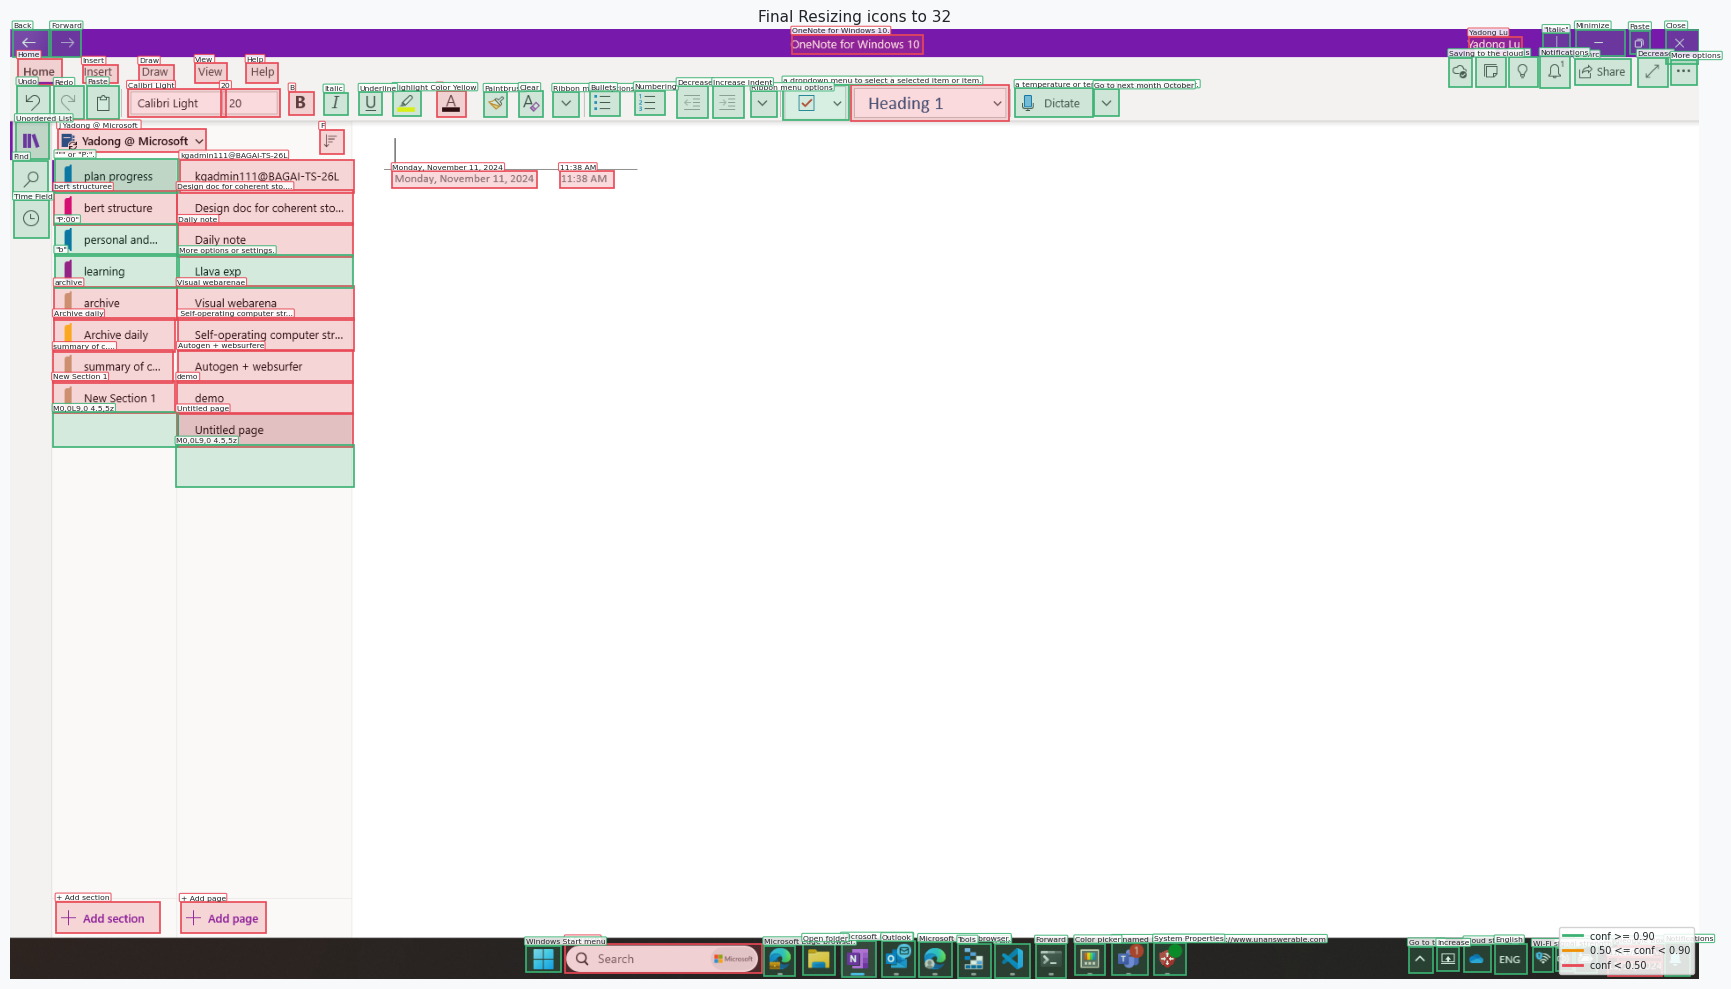

In [21]:
icons  = [elem for elem in filtered_boxes if elem['content']] + [{**elem, 'content': gen_caption} for elem, gen_caption in zip(icon_wo_content,icons_captions_32)]
visualize_boxes(image_np, [elem['bbox'] for elem in icons], 
                labels=[elem['content'] for elem in icons], 
                confidences=[0.2 if 'ocr' in elem['source'] else 1 for elem in icons], 
                title="Final Resizing icons to 32")

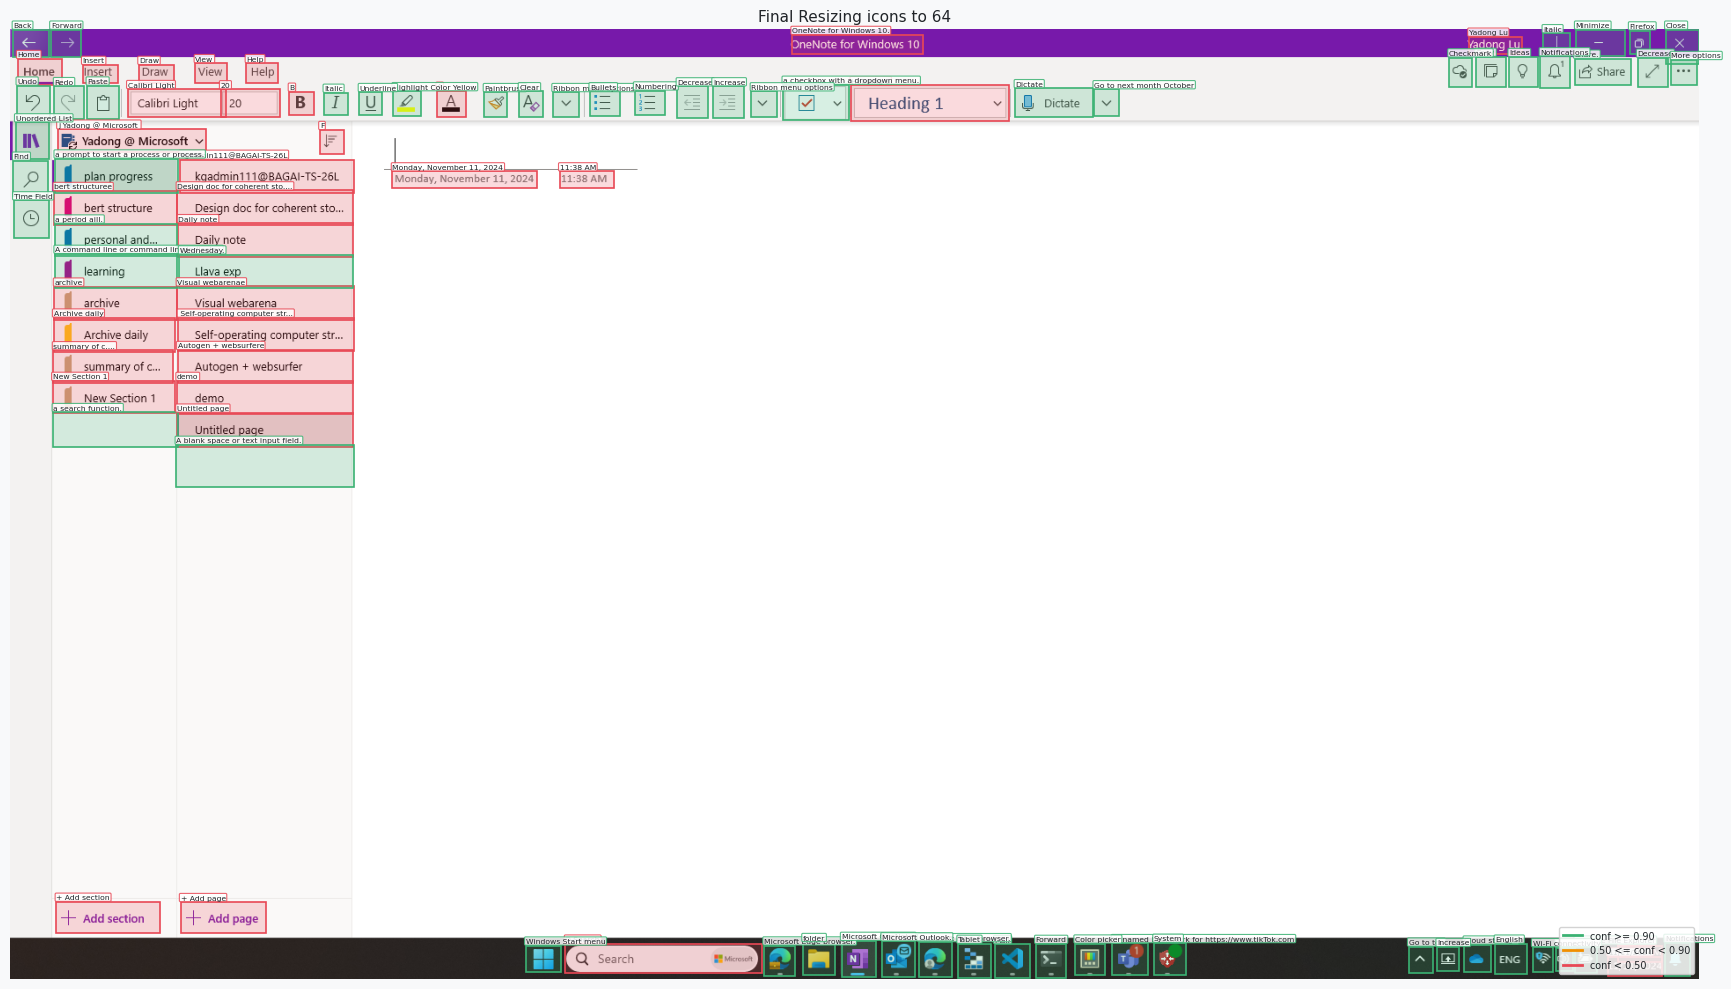

In [22]:
icons  = [elem for elem in filtered_boxes if elem['content']] + [{**elem, 'content': gen_caption} for elem, gen_caption in zip(icon_wo_content,icons_captions_64)]
visualize_boxes(image_np, [elem['bbox'] for elem in icons], 
                labels=[elem['content'] for elem in icons], 
                confidences=[0.2 if 'ocr' in elem['source'] else 1 for elem in icons], 
                title="Final Resizing icons to 64")

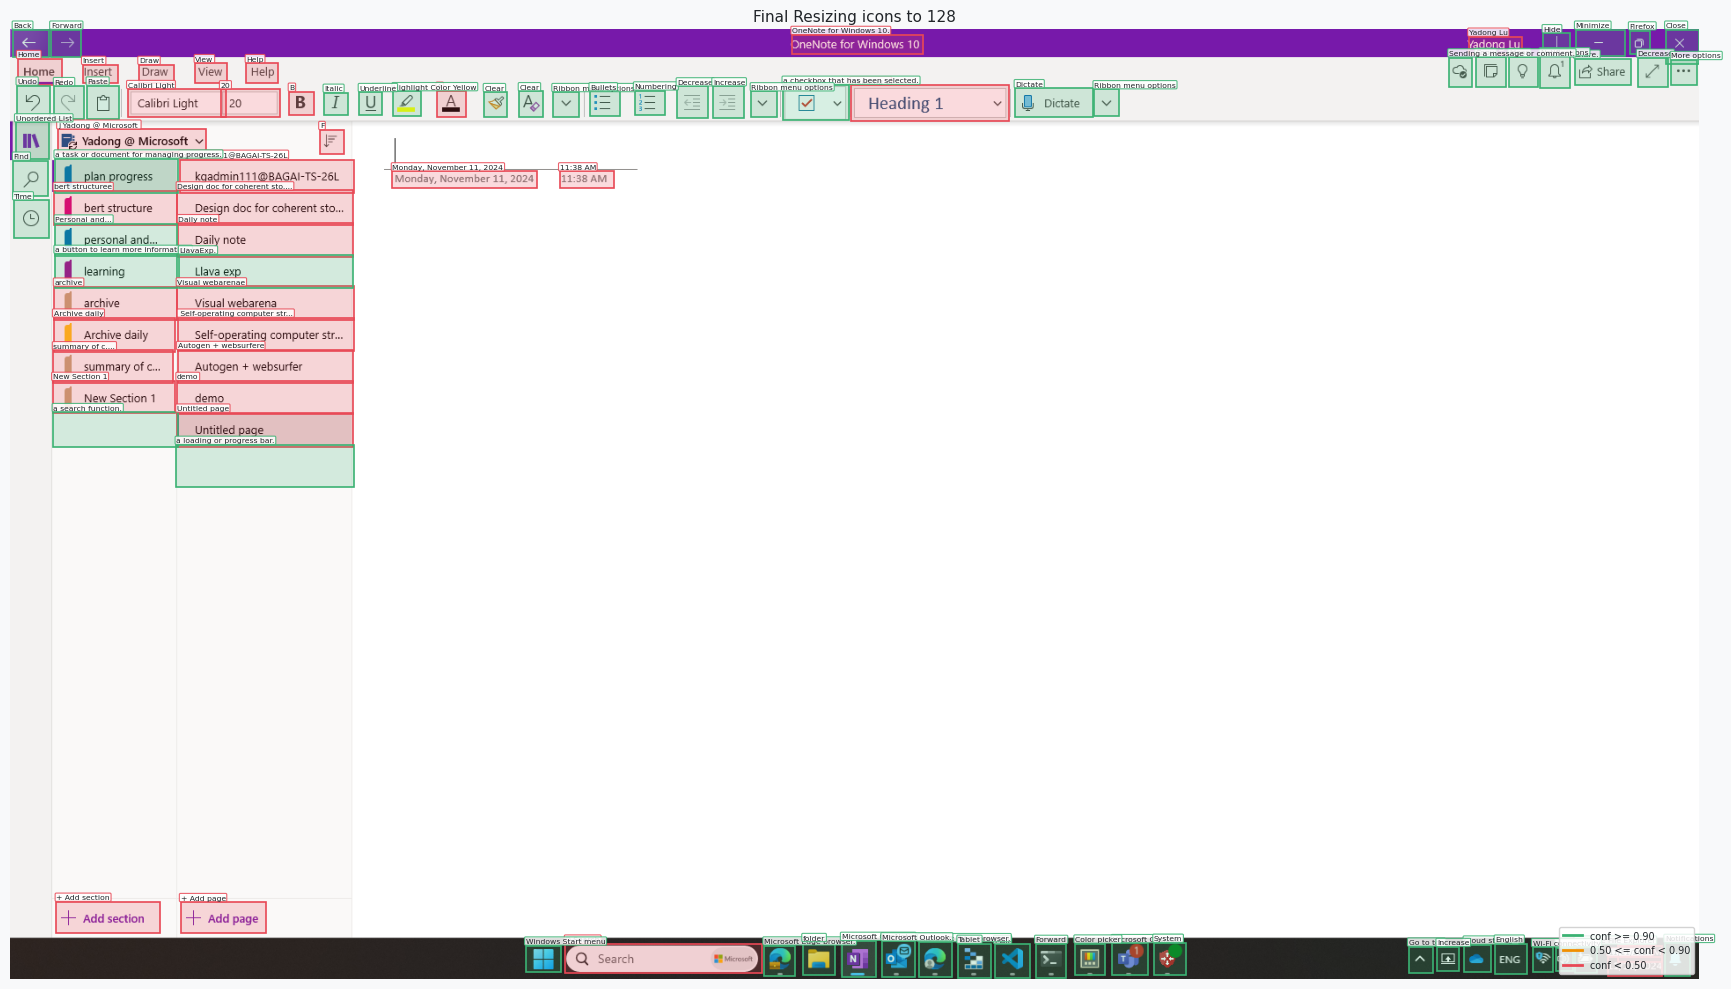

In [23]:
icons  = [elem for elem in filtered_boxes if elem['content']] + [{**elem, 'content': gen_caption} for elem, gen_caption in zip(icon_wo_content,icons_captions_128)]
visualize_boxes(image_np, [elem['bbox'] for elem in icons], 
                labels=[elem['content'] for elem in icons], 
                confidences=[0.2 if 'ocr' in elem['source'] else 1 for elem in icons], 
                title="Final Resizing icons to 128")

In [24]:
# printting different captions generated with different icon sizes with number of icon to debug
[(i, captions) for i, captions in enumerate(zip(icons_captions_128, icons_captions_64)) if captions[0] != captions[1]]

[(0,
  ('a button to learn more information.',
   'A command line or command line indicator.')),
 (1, ('Personal and...', 'a period aill.')),
 (2,
  ('a task or document for managing progress.',
   'a prompt to start a process or process.')),
 (3,
  ('a checkbox that has been selected.', 'a checkbox with a dropdown menu.')),
 (4, ('LlavaExp.', 'Wednesday.')),
 (6, ('Time', 'Time Field')),
 (18, ('Microsoft Outlook.', 'Unnamed bookmark for https://www.tikTok.com')),
 (32, ('Clear', 'Paintbrush')),
 (42, ('Sending a message or comment.', 'Checkmark')),
 (50, ('Ribbon menu options', 'Go to next month October')),
 (55, ('a loading or progress bar.', 'A blank space or text input field.')),
 (56, ('Hide', 'Italic'))]

* **Results of different icon sizes**
    - 0. is total wrong
    - 1. 128 is correct
    - 2. 128 better that 64
    - 3. 64 is better, but both are good
    - 4. 128 is better
    - 6. both equal
    - 18. 128 is correct
    - 32. 64 is correct
    - 42. both are wrong
    - 50. 128 is correct
    - 55. both wrong because icon detectoin detect it wrongly
    - 56. both wrong because icon detection detect it wrongly

In [25]:
to_pil = ToPILImage()
h, w, _ = image_np.shape
croped_pil_image = []
# --- crop icons ---
for i, coord in enumerate(icon_wo_content_bboxs):
    xmin, xmax = int(coord[0]*w), int(coord[2]*w)
    ymin, ymax = int(coord[1]*h), int(coord[3]*h)
    cropped_image = image_np[ymin:ymax, xmin:xmax, :]
    h_c, w_c = cropped_image.shape[:2]
    scale = 128 / max(h_c, w_c)
    new_w, new_h = int(w_c * scale), int(h_c * scale)
    cropped_image = cv2.resize(cropped_image, (new_w, new_h))
    croped_pil_image.append(to_pil(cropped_image))

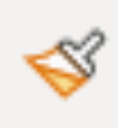

In [26]:
croped_pil_image[32]

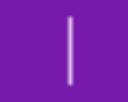

In [27]:
croped_pil_image[56]

In [28]:
filtered_boxes

[{'type': 'text',
  'bbox': array([    0.46274,   0.0055607,     0.54039,     0.02595], dtype=float32),
  'interactivity': False,
  'content': 'OneNote for Windows 10.',
  'source': 'box_ocr_content_ocr'},
 {'type': 'text',
  'bbox': array([    0.86347,   0.0074143,     0.89474,     0.02595], dtype=float32),
  'interactivity': False,
  'content': 'Yadong Lu',
  'source': 'box_ocr_content_ocr'},
 {'type': 'text',
  'bbox': array([   0.042731,    0.037071,    0.063575,    0.056534], dtype=float32),
  'interactivity': False,
  'content': 'Insert',
  'source': 'box_ocr_content_ocr'},
 {'type': 'text',
  'bbox': array([   0.076081,    0.037071,    0.096925,    0.056534], dtype=float32),
  'interactivity': False,
  'content': 'Draw',
  'source': 'box_ocr_content_ocr'},
 {'type': 'text',
  'bbox': array([    0.10943,    0.035218,     0.12819,    0.056534], dtype=float32),
  'interactivity': False,
  'content': 'View',
  'source': 'box_ocr_content_ocr'},
 {'type': 'text',
  'bbox': array([    

In [29]:
icons  = [elem for elem in filtered_boxes if elem['content']] + [{**elem, 'content': gen_caption} for elem, gen_caption in zip(icon_wo_content,icons_captions_128)]


## Vision Model

In [30]:
import os                                                                                                                                  
from dotenv import load_dotenv                                                                                                             
from google import genai
from google.genai import types                                                                                                             
import base64                                                                                                                              
from PIL import Image                                                                                                                      
import io                                                                                                                                  
                                                                                                                                            
load_dotenv()                                                                                                                              
                                                                                                                                            
client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

In [54]:
from torchvision.ops import box_convert

from util.box_annotator import BoxAnnotator 
import supervision as sv



def annotate(image_np: np.ndarray, icons: list, text_scale: float, text_padding=5, text_thickness=2, thickness=3) -> np.ndarray:
    """    
    This function annotates an image with bounding boxes and labels.

    Parameters:
    image_np (np.ndarray): The source image to be annotated.
    text_scale (float): The scale of the text to be displayed. 0.8 for mobile/web, 0.3 for desktop # 0.4 for mind2web

    Returns:
    np.ndarray: The annotated image.
    """
    h, w, _ = image_np.shape
    boxes = np.array([list(icon['bbox']) for icon in icons])
    phrases = [icon['content'] for icon in icons]
    boxes = boxes * np.array([w, h, w, h])
    
    detections = sv.Detections(xyxy=boxes)
    ids = [f"{phrase}" for phrase in range(boxes.shape[0])]

    box_annotator = BoxAnnotator(text_scale=text_scale, text_padding=text_padding,text_thickness=text_thickness,thickness=thickness) # 0.8 for mobile/web, 0.3 for desktop # 0.4 for mind2web
    annotated_frame = image_np.copy()
    annotated_frame = box_annotator.annotate(scene=annotated_frame, detections=detections, labels=ids, image_size=(w,h))

    label_coordinates = {f"{iid}": icon for iid, icon in zip(ids, icons)}
    return annotated_frame, label_coordinates

In [43]:
draw_bbox_config

{'text_scale': 0.47975000000000007,
 'text_thickness': 1,
 'text_padding': 1,
 'thickness': 1}

In [55]:
annotated_frame, label_coordinates = annotate(image_np, icons, **draw_bbox_config)

In [60]:
# label_coordinates

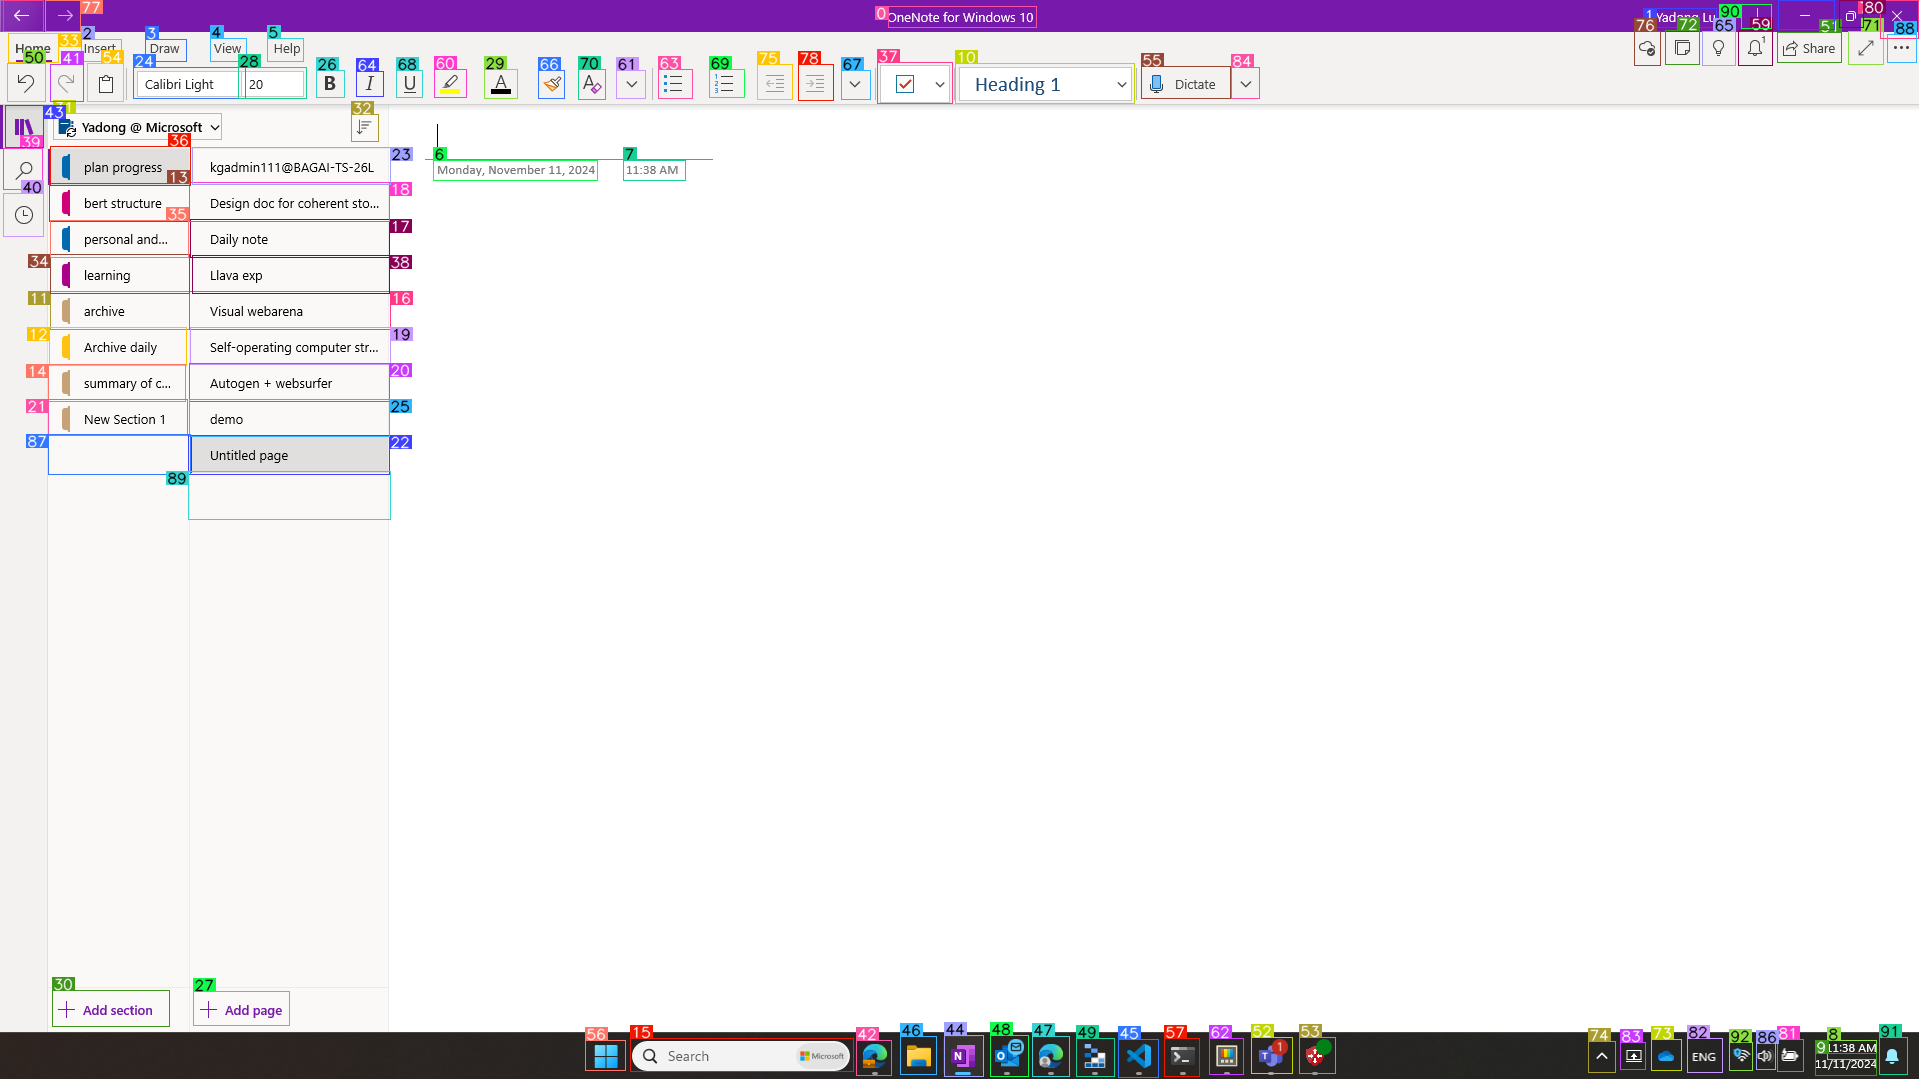

In [58]:
Image.fromarray(annotated_frame)

In [ ]:
OMNIPARSER_ORIGINAL_PROMPT = (
    "The instruction is to {}.\n"
    "Here is the list of all detected bounding boxes by IDs and their descriptions: {}.\n"
    "Keep in mind the description for Text Boxes are likely more accurate than the description for Icon Boxes.\n" 
    "Requirement:\n" 
    "1. You should first give a reasonable description of the current screenshot, and give a some analysis of how can the user instruction be achieved by a single click. \n"
    "2. Then make an educated guess of bbox id to click in order to complete the task using both the visual information from the screenshot image and the bounding boxes descriptions.\n"
    "REMEMBER: the task instruction must be achieved by one single click."
    "3. Your answer should follow the following format: {{'Analysis': 'xxx', 'Click BBox ID': 'y'}}."
    "Please do not include any other info.")

In [69]:
SYSTEM_PROMPT = """
You are a GUI agent. You will be given a screenshot and a list of detected UI elements,
each with an ID and a text label or icon caption.

Note: Text Box descriptions are generally more accurate than Icon Box descriptions.

Use both the screenshot and the element list to reason about the current UI state,
then identify the single element to click to best advance the instruction.

Requirements:
1. Briefly describe the current screenshot and the relevant UI context.
2. Analyze how the instruction can be achieved by a single click, considering both
   the visual layout and the element descriptions.
3. Select the ID of the element to click.

Output strictly as JSON:
{
  "analysis": "<screenshot description and reasoning>",
  "click_id": "<ID of element to click>"
}

The task must be completed with one single click. Do not include any other information.
"""

USER_PROMPT_TEMPLATE = """
The user's instruction is: {instruction}

Detected UI elements (IDs and descriptions):
{elements}
"""


def pil_to_part(image: Image.Image, fmt: str = "PNG") -> types.Part:
    buf = io.BytesIO()
    image.save(buf, format=fmt)
    return types.Part.from_bytes(
        data=buf.getvalue(),
        mime_type=f"image/{fmt.lower()}",
    )

In [ ]:
user_task = "create new page"
elements = "\n".join([f"\t[{i}] type={elem['type']}  content={elem['content']!r}"
                      for i, elem in label_coordinates.items()])

user_text = USER_PROMPT_TEMPLATE.format(instruction=user_task, elements=elements)


response = client.models.generate_content(
    model='gemini',
    config=types.GenerateContentConfig(
        system_instruction=SYSTEM_PROMPT,
        response_mime_type="application/json",
    ),
    contents=[
        types.Content(role="user", parts=[
            pil_to_part(Image.fromarray(annotated_frame)),
            types.Part.from_text(user_text),
        ])
    ],
)


	[0] type=text  content='OneNote for Windows 10.'
	[1] type=text  content='Yadong Lu'
	[2] type=text  content='Insert'
	[3] type=text  content='Draw'
	[4] type=text  content='View'
	[5] type=text  content='Help'
	[6] type=text  content='Monday, November 11, 2024'
	[7] type=text  content='11:38 AM'
	[8] type=text  content='11:38 AM'
	[9] type=text  content='11/11/2024'
	[10] type=icon  content='Heading 1'
	[11] type=icon  content='archive'
	[12] type=icon  content='Archive daily'
	[13] type=icon  content='bert structuree'
	[14] type=icon  content='summary of c....'
	[15] type=icon  content='Q Search'
	[16] type=icon  content='Visual webarenae'
	[17] type=icon  content='Daily note'
	[18] type=icon  content='Design doc for coherent sto....'
	[19] type=icon  content=' Self-operating computer str...'
	[20] type=icon  content='Autogen + websurfere'
	[21] type=icon  content='New Section 1'
	[22] type=icon  content='Untitled page'
	[23] type=icon  content='kgadmin111@BAGAI-TS-26L'
	[24] type=i